In [ ]:
!nvidia-smi

Sun Oct 26 15:08:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="wGV0mHPPRiCABg2IzqWO")
project = rf.workspace("sude-1n3gj").project("red-blue-balloon-detection-yq5xy")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to “Red–Blue-Balloon-Detection”-1 in yolov8:: 100%|██████████| 9796/9796 [00:01<00:00, 9384.14it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!mv /content/*Balloon* /content/Red-Blue-Balloon-Detection-1



mv: cannot move '/content/Red-Blue-Balloon-Detection-1' to a subdirectory of itself, '/content/Red-Blue-Balloon-Detection-1/Red-Blue-Balloon-Detection-1'


In [ ]:
!ls /content


Red-Blue-Balloon-Detection-1  runs  sample_data  yolov8n.pt


In [ ]:
!ls runs/detect


balloon_yolov8n_run1   balloon_yolov8n_run13
balloon_yolov8n_run12  balloon_yolov8n_run14


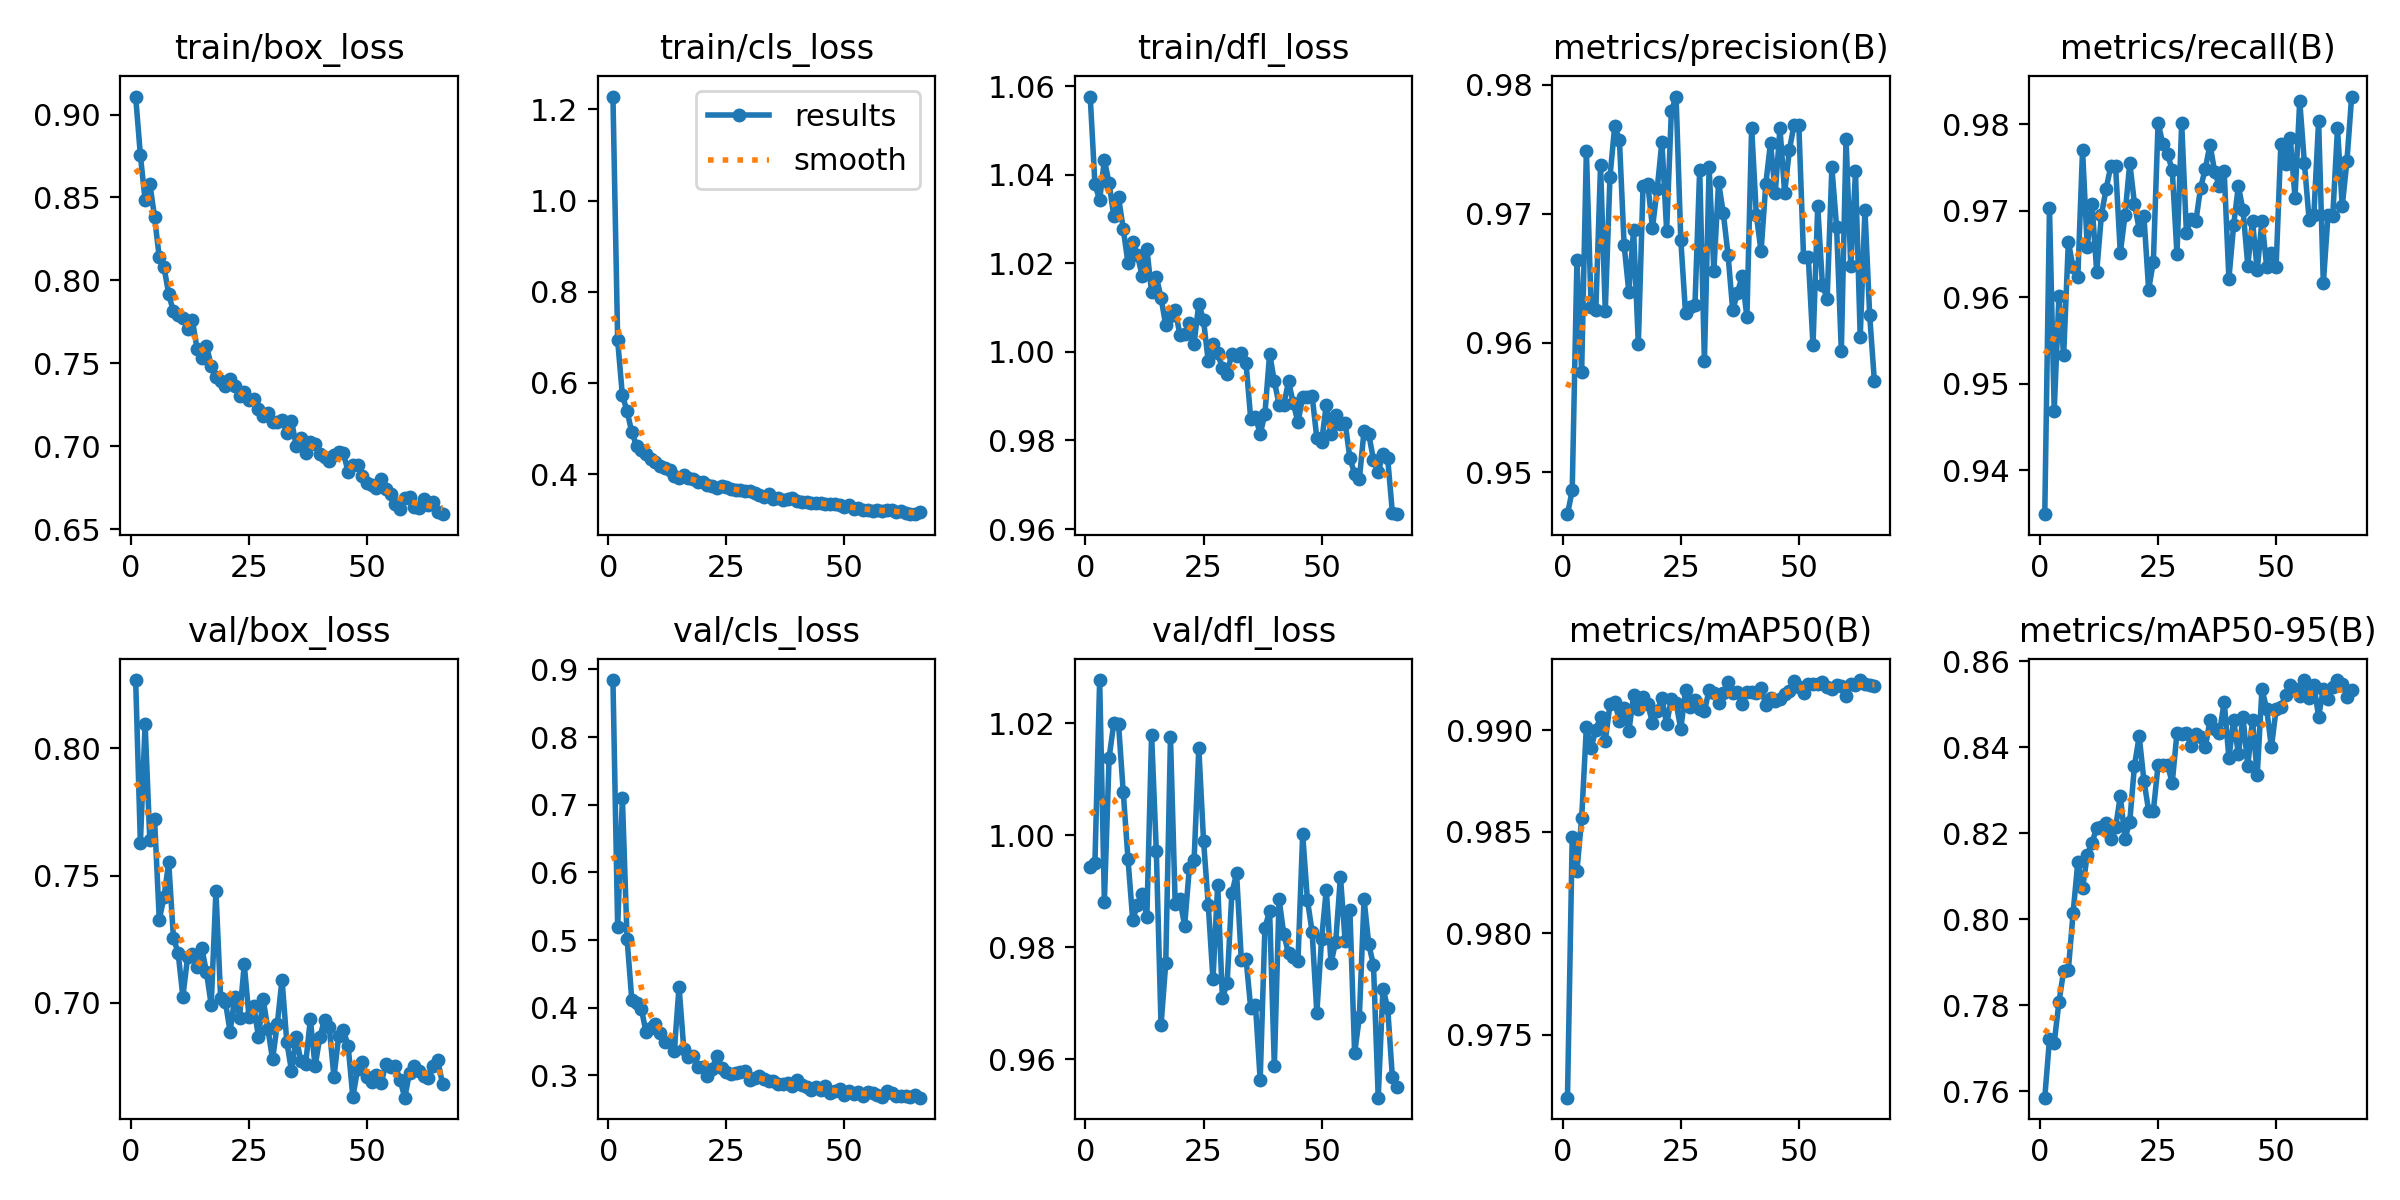

In [ ]:
from IPython.display import Image, display

# Precision, Recall, mAP grafikleri
display(Image(filename="runs/detect/balloon_yolov8n_run14/results.png"))



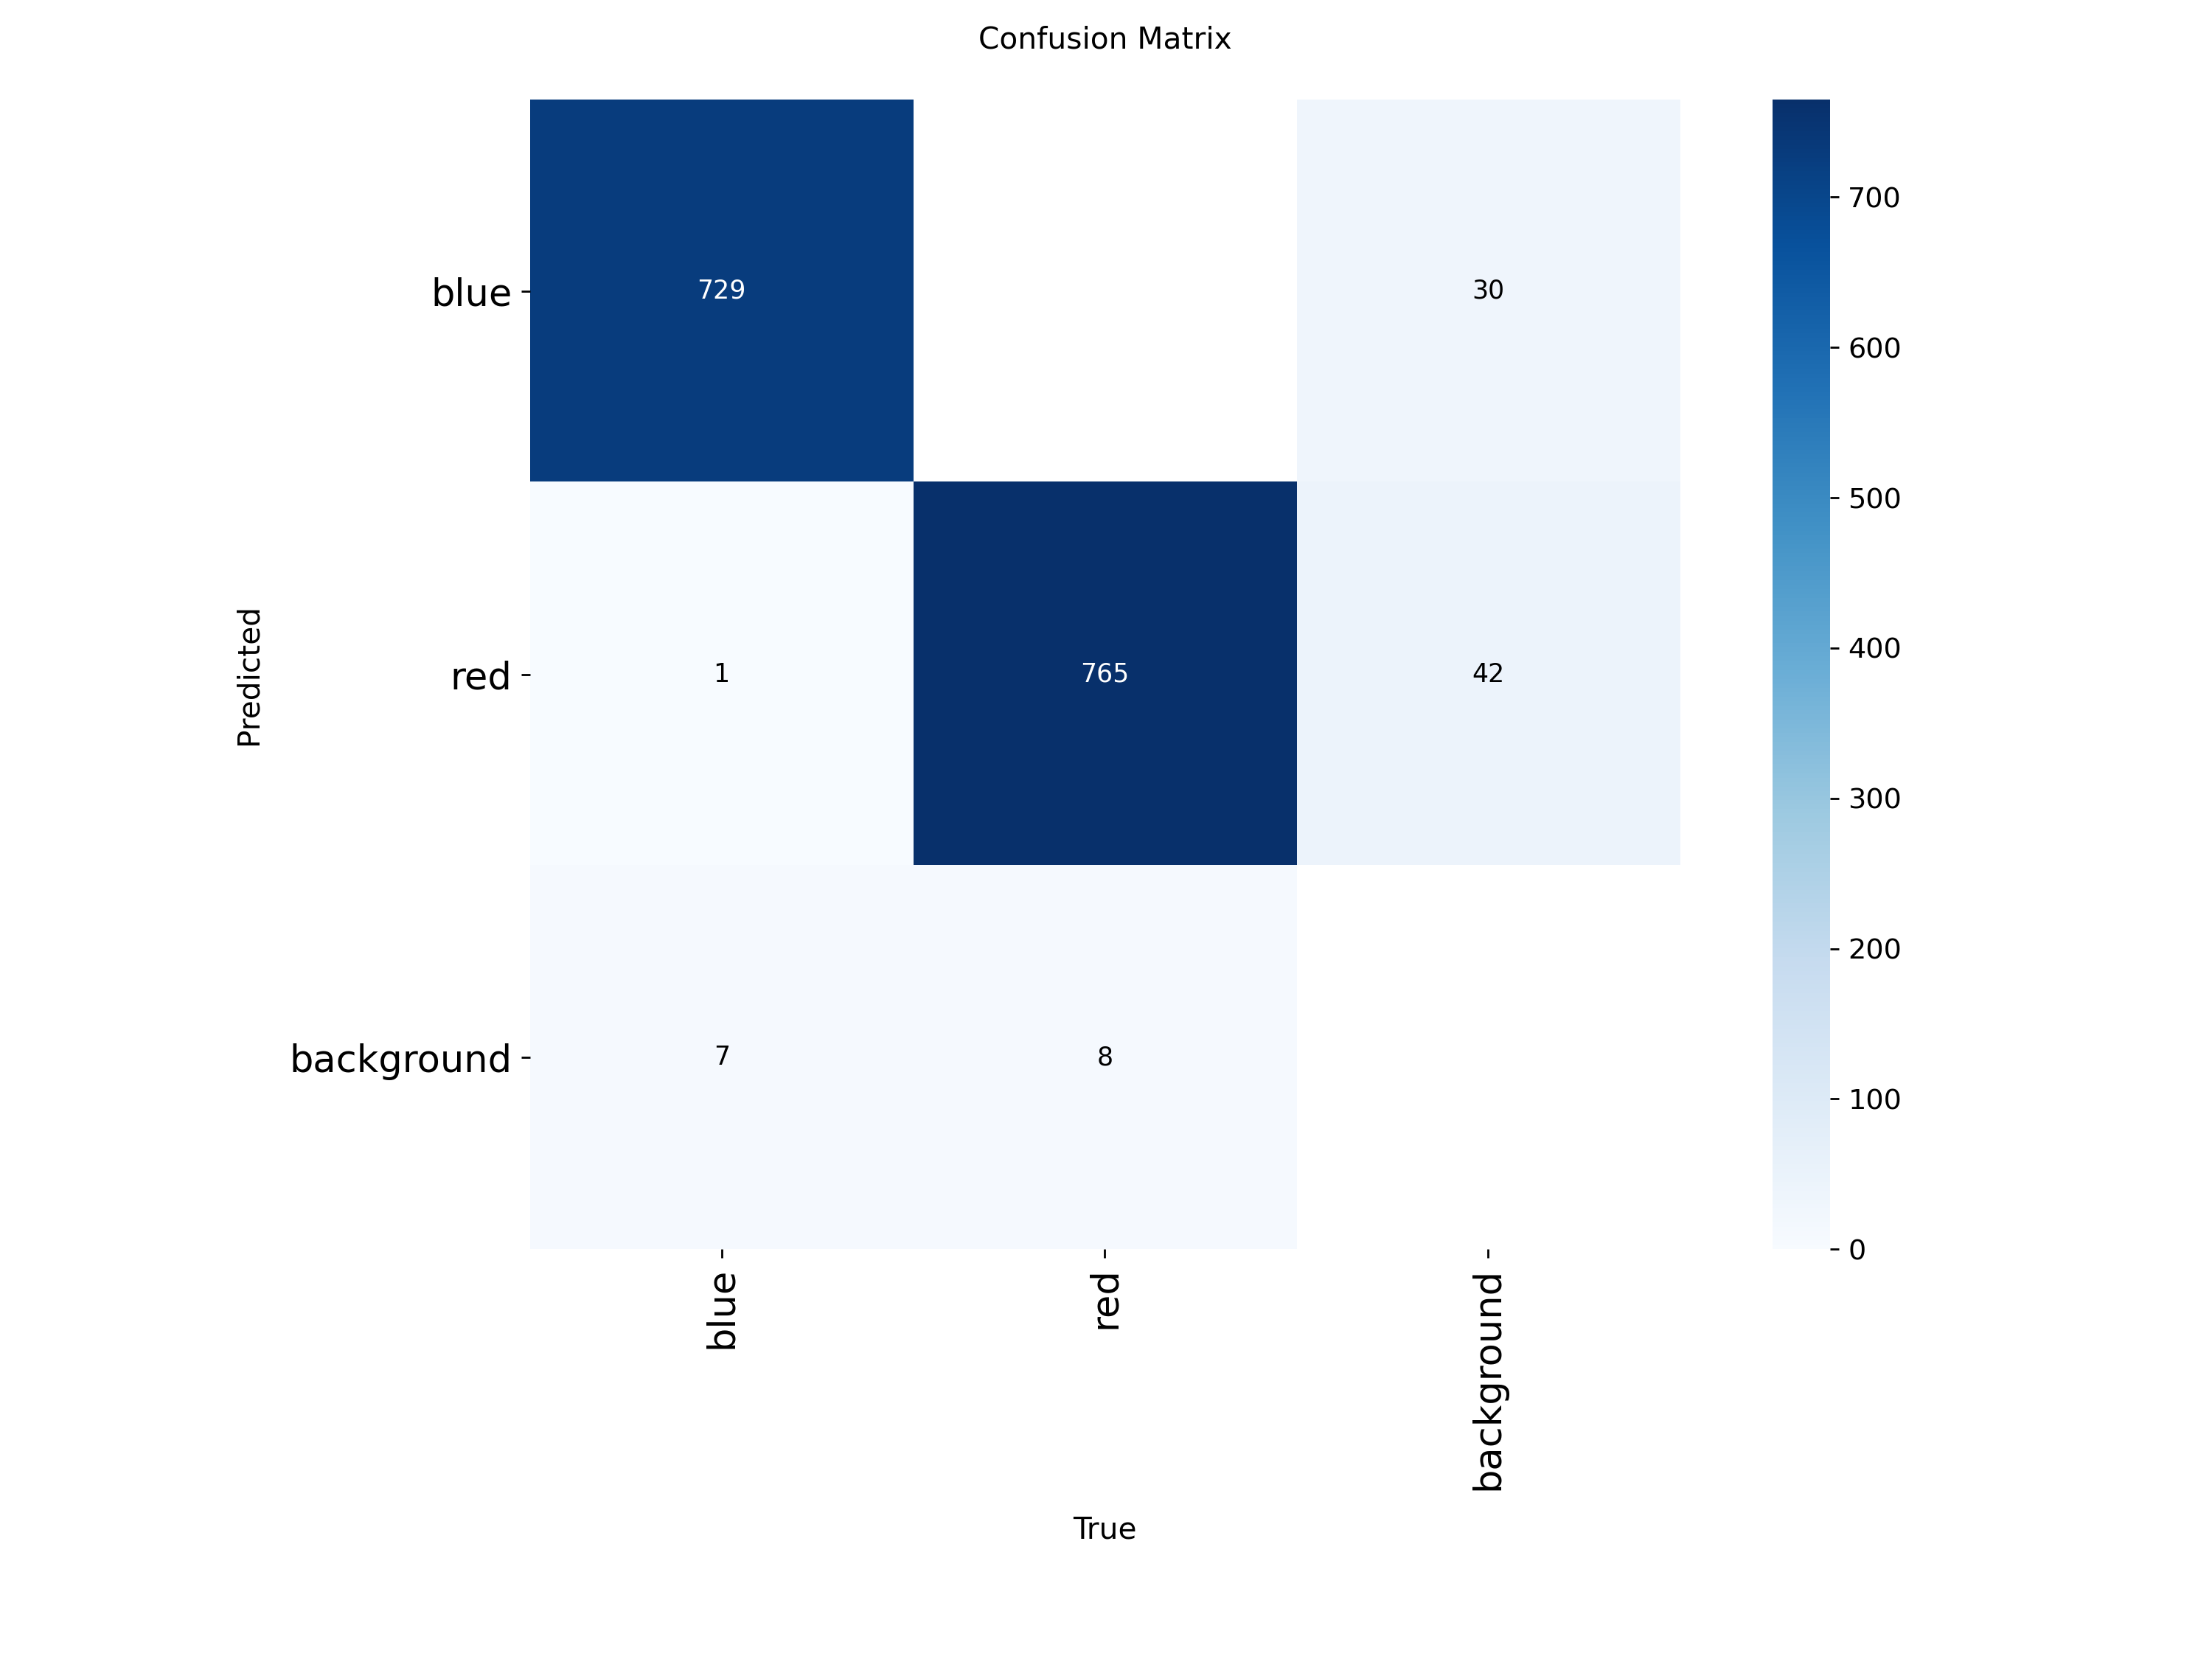

In [ ]:
from IPython.display import Image, display

# Sınıf karışıklık matrisi (hangi sınıfla karıştı)
display(Image(filename="runs/detect/balloon_yolov8n_run14/confusion_matrix.png"))

In [ ]:
from ultralytics import YOLO

# 1️⃣ En iyi eğitilmiş modelini yükle
model = YOLO("runs/detect/balloon_yolov8n_run14/weights/best.pt")

# 2️⃣ Validation (değerlendirme) işlemini başlat
metrics = model.val(
    data="/content/Red-Blue-Balloon-Detection-1/data.yaml",  # dataset yolu
    imgsz=640,      # Görüntü boyutu
    batch=32,       # Batch size
    conf=0.001,     # Confidence threshold (çok düşük tut, her tespiti değerlendir)
    iou=0.7,        # IoU threshold
    device=0        # GPU
)

# 3️⃣ Sonuçları yazdır
print("\n=== VALIDATION SONUÇLARI ===")
print(f"Precision: {metrics.box.map50:.3f}")
print(f"Recall:    {metrics.box.map:.3f}")
print(f"mAP@50:    {metrics.box.map50:.3f}")
print(f"mAP@50-95: {metrics.box.map75:.3f}")


Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1145.4±321.3 MB/s, size: 37.9 KB)
val: Scanning /content/Red-Blue-Balloon-Detection-1/valid/labels.cache... 577 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 577/577 1.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.7it/s 4.0s
                   all        577       1510      0.963      0.975      0.992      0.855
                  blue        489        737      0.969      0.977      0.993      0.854
                   red        483        773      0.958      0.974      0.991      0.856
Speed: 1.3ms preprocess, 1.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val

=== VALIDATION SONUÇLARI ===
Precision: 0.992
Recall:    0.855
mAP@50

In [ ]:
from google.colab import files

uploaded = files.upload()  # 💡 Buradan kendi video dosyanı seç


Saving testvideo.MOV to testvideo.MOV


In [ ]:
from ultralytics import YOLO

# 1️⃣ Eğitilmiş modelini yükle
model = YOLO("runs/detect/balloon_yolov8n_run14/weights/best.pt")

# 2️⃣ Videonun yolunu belirt (.MOV dosyan)
input_video = "testvideo.MOV"

# 3️⃣ Model ile tespit işlemini başlat
results = model.predict(
    source=input_video,   # test edilecek video
    conf=0.4,             # güven eşiği (düşürürsen daha fazla tespit yapar)
    iou=0.5,              # IoU eşiği
    save=True,            # çıktıyı kaydet
    project="runs/detect",
    name="mov_test",      # çıktı klasör adı
    device=0              # GPU kullan
)

print("✅ Video işlendi! Sonuçlar burada kaydedildi:")
print("runs/detect/mov_test")



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 68.8ms
video 1/1 (frame 2/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 10.7ms
video 1/1 (frame 3/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 9.9ms
video 1/1 (frame 4/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.5ms
video 1/1 (frame 5/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.3ms
video 1/1 (frame 6/568) /content/testvideo.MOV: 640x384 1 blue, 

In [ ]:
from ultralytics import YOLO
import cv2

# 1️⃣ Modeli yükle
model = YOLO("runs/detect/balloon_yolov8n_run14/weights/best.pt")

# 2️⃣ Videoyu oku
input_video = "testvideo.MOV"

# 3️⃣ Tahmin yap (YOLO orijinal kutuları çizsin)
results = model.predict(
    source=input_video,
    conf=0.4,
    save=False,
    stream=True,
    device=0
)

# 4️⃣ Video çıktı ayarları
cap = cv2.VideoCapture(input_video)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter("final_colored.mov", cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

# 5️⃣ Her frame için kutuları kontrol et
for result in results:
    frame = result.plot()  # YOLO’nun kendi çizimi (güzel kalın kutularla)
    boxes = result.boxes
    names = model.names

    # Kırmızı kutuların rengini manuel olarak değiştir
    for box in boxes:
        cls_id = int(box.cls[0])
        label = names[cls_id]
        if label == "red":
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 3)  # sadece kırmızı kutu ekle

    out.write(frame)

cap.release()
out.release()

print("✅ Yeni video kaydedildi: final_colored.mov")




video 1/1 (frame 1/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 10.9ms
video 1/1 (frame 2/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.7ms
video 1/1 (frame 3/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.4ms
video 1/1 (frame 4/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.3ms
video 1/1 (frame 5/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.4ms
video 1/1 (frame 6/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.3ms
video 1/1 (frame 7/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 10.8ms
video 1/1 (frame 8/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.5ms
video 1/1 (frame 9/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.4ms
video 1/1 (frame 10/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.4ms
video 1/1 (frame 11/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.4ms
video 1/1 (frame 12/568) /content/testvideo.MOV: 640x384 1 blue, 2 reds, 7.4ms
video 1/1 (frame 13/568) /content/testvideo.MOV: 640x384 1